In [ ]:
!git clone https://github.com/juanmafdez/LLP_APP_Colombia

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
import os, sys, glob, json, shutil, random
import numpy as np
import pandas as pd
import geopandas as gpd
import tifffile
from pathlib import Path
from PIL import Image
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import tensorflow as tf

In [24]:
sys.path.append('LLP_APP_Colombia/swav')
import architecture
import multicrop_dataset

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
data_path   = '/content/drive/MyDrive/llp_col_project/datasets/sentinel'
final_output = '/content/train_data'
os.makedirs(final_output, exist_ok=True)

In [8]:
departments = {
    'tolima': 'tol_partitions_aschips_2c14c05f234fb'
}

for alias, folder_name in departments.items():
    print(f'--- Unzipping {alias} ---')
    !unzip -o -q {data_path}/{folder_name}.zip -d /content/
    full_path = f'/content/*/{folder_name}/sentinel2-rgb-median-2020'
    found_dirs = glob.glob(full_path)
    if found_dirs:
        src_dir = found_dirs[0]
        files = os.listdir(src_dir)
        print(f'Found files: {len(files)}')
        for f in files:
            src_file = os.path.join(src_dir, f)
            dst_file = os.path.join(final_output, f)
            shutil.move(src_file, dst_file)
        print(f'{alias} moved correctly.')
    else:
        print(f'{alias} not found.')
    !rm -rf /content/gjson_data*
print(f'Total files in {final_output}: {len(os.listdir(final_output))}')

--- Unzipping tolima ---
Found files: 23902
tolima moved correctly.
Total files in /content/train_data: 23902


In [9]:
GJSON_CHIPS = '/content/drive/MyDrive/llp_col_project/datasets/sentinel/geojson_sentinel/tol_partitions_aschips_2c14c05f234fb.geojson'
GJSON_LABEL = '/content/drive/MyDrive/llp_col_project/datasets/esawc/tolima/tol_partitions_aschips_2c14c05f234fb.geojson'

BACKBONE_WEIGHTS = '/content/drive/MyDrive/llp_col_project/swav_checkpoints/feature_backbone_latest.weights.h5'

SRC_DIR = '/content/train_data'
PNG_DIR = '/content/train_data_png8'
os.makedirs(PNG_DIR, exist_ok=True)

In [10]:
def save_png8_from_array(img_np: np.ndarray, out_path: str):
    if img_np.ndim == 3 and img_np.shape[0] < img_np.shape[1]:
        img_np = np.transpose(img_np, (1, 2, 0))
    elif img_np.ndim == 2:
        img_np = img_np[..., None]
    if img_np.shape[-1] == 1:
        img_np = np.repeat(img_np, 3, axis=-1)
    elif img_np.shape[-1] > 3:
        img_np = img_np[..., :3]
    arr = img_np.astype(np.uint8)
    Image.fromarray(arr).save(out_path, format='PNG', compress_level=0)

tif_paths = sorted(glob.glob(os.path.join(SRC_DIR, '*.tif')))
print(f'Converting {len(tif_paths)} TIFFs to PNG 8-bit...')
converted = 0
for p in tif_paths:
    out_path = os.path.join(PNG_DIR, Path(p).stem + '.png')
    if not os.path.exists(out_path):
        arr = tifffile.imread(p)
        save_png8_from_array(arr, out_path)
        converted += 1
print(f'Done. Converted: {converted}. '
      f'Total PNGs: {len(glob.glob(os.path.join(PNG_DIR, "*.png")))}')

Converting 23902 TIFFs to PNG 8-bit...
Done. Converted: 23902. Total PNGs: 23902


In [18]:
def extraer_prop_ewc(d):
    if isinstance(d, str):
        try:
            d = json.loads(d)
        except Exception:
            import ast
            d = ast.literal_eval(d)
    return float(d.get('1', 0.0))

gdf_chips = gpd.read_file(GJSON_CHIPS)
gdf_lab   = gpd.read_file(GJSON_LABEL)

gdf_lab['prop_chip'] = gdf_lab['esaworldcover-2020_proportions'].apply(extraer_prop_ewc)
chips = gdf_chips.merge(gdf_lab[['identifier', 'prop_chip', 'split_municipalities']], on='identifier', how='inner')

print(f'Total chips loaded: {len(chips)}')
print(f'Split distribution:\n{chips["split_municipalities"].value_counts()}')

Total chips loaded: 23902
Split distribution:
split_municipalities
train    13629
test      6485
val       3788
Name: count, dtype: int64


In [20]:
# -- Geographically correct split: train+val / test by municipality
# val is folded into train (no hyperparameter search / early stopping)
train_ids = chips.query("split_municipalities in ('train', 'val')")['identifier'].tolist()
test_ids  = chips.query("split_municipalities == 'test'")['identifier'].tolist()

print(f'\nTrain chips (train+val municipalities): {len(train_ids)}')
print(f'Test chips  (test municipalities):       {len(test_ids)}')
# print(f'Train municipalities: '
#       f'{chips.query("split_municipalities in (\"train\",\"val\")")["foreignid_municipalities"].nunique()}')
# print(f'Test  municipalities: '
#       f'{chips.query("split_municipalities == \"test\"")["foreignid_municipalities"].nunique()}')


Train chips (train+val municipalities): 17417
Test chips  (test municipalities):       6485


In [21]:
def load_image(identifier: str) -> np.ndarray:
    path = os.path.join(PNG_DIR, identifier + '.png')
    img = Image.open(path).convert('RGB')
    return np.array(img, dtype=np.float32) / 255.0

# -- Build arrays -------------------------------------------
print('\nLoading train images...')
id_to_prop = dict(zip(gdf_lab['identifier'], gdf_lab['prop_chip']))

X_train = np.stack([load_image(i) for i in train_ids])
y_train = np.array([id_to_prop[i] for i in train_ids], dtype=np.float32)

print('Loading test images...')
X_test  = np.stack([load_image(i) for i in test_ids])
y_test  = np.array([id_to_prop[i] for i in test_ids], dtype=np.float32)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
def load_image(identifier: str) -> np.ndarray:
    path = os.path.join(PNG_DIR, identifier + '.png')
    img = Image.open(path).convert('RGB')
    return np.array(img, dtype=np.float32) / 255.0

# -- Build arrays -------------------------------------------
print('\nLoading train images...')
id_to_prop = dict(zip(gdf_lab['identifier'], gdf_lab['prop_chip']))

X_train = np.stack([load_image(i) for i in train_ids])
y_train = np.array([id_to_prop[i] for i in train_ids], dtype=np.float32)

print('Loading test images...')
X_test  = np.stack([load_image(i) for i in test_ids])
y_test  = np.array([id_to_prop[i] for i in test_ids], dtype=np.float32)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')



Loading train images...
Loading test images...
X_train: (17417, 100, 100, 3) | y_train: (17417,)
X_test:  (6485, 100, 100, 3)  | y_test:  (6485,)

Loading train images...
Loading test images...
X_train: (17417, 100, 100, 3) | y_train: (17417,)
X_test:  (6485, 100, 100, 3)  | y_test:  (6485,)


In [22]:
# ===========================================================
# MODULE 5: Model builder
# ===========================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def build_model(pretrained: bool = False) -> tf.keras.Model:
    """
    ResNet backbone + single sigmoid head (matches LLP architecture).
    pretrained=True loads SwAV weights before adding the head.
    """
    backbone = architecture.get_resnet_backbone()
    if pretrained:
        backbone.load_weights(BACKBONE_WEIGHTS)
        print('SwAV weights loaded.')
    x = backbone.output
    x = Flatten()(x)
    x = Dense(1, activation='sigmoid', name='head')(x)
    model = Model(inputs=backbone.input, outputs=x)
    return model

# ===========================================================
# MODULE 6: Metrics
# ===========================================================

def compute_metrics(model, X, y, label=''):
    y_pred = model.predict(X, verbose=0).ravel()
    rmse   = float(np.sqrt(mean_squared_error(y, y_pred)))
    r, _   = pearsonr(y, y_pred)
    print(f'[{label}] RMSE: {rmse:.4f}  r: {r:.4f}')
    return {'rmse': rmse, 'r': r}

In [25]:
# ===========================================================
# MODULE 7: Training — Scratch
# ===========================================================

print('\n' + '='*50)
print('EXPERIMENT 1: Scratch (random initialization)')
print('='*50)

model_scratch = build_model(pretrained=False)
model_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse'
)

history_scratch = model_scratch.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    verbose=1
)

print('\n--- Scratch: Final metrics ---')
scratch_train = compute_metrics(model_scratch, X_train, y_train, 'Train')
scratch_test  = compute_metrics(model_scratch, X_test,  y_test,  'Test')


EXPERIMENT 1: Scratch (random initialization)
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 144s 573ms/step - loss: 0.0638 - val_loss: 0.0846
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 50s 363ms/step - loss: 0.0264 - val_loss: 0.2746
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 357ms/step - loss: 0.0215 - val_loss: 0.3137
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - loss: 0.0178 - val_loss: 0.0766
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - loss: 0.0192 - val_loss: 0.0341
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 359ms/step - loss: 0.0149 - val_loss: 0.0270
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - loss: 0.0121 - val_loss: 0.0211
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 360ms/step - loss: 0.0107 - val_loss: 0.0648
Epoch 9/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 360ms/step - loss: 0.0129 - val_loss: 0.0305
Epoch 10/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 360ms/step - loss: 0.0101 - val_loss: 0.0278

--- Scratch: Final metrics ---
[Train] RMSE: 0.1604  r: 0.86

In [26]:
# ===========================================================
# MODULE 8: Training — SwAV pretrained
# ===========================================================

print('\n' + '='*50)
print('EXPERIMENT 2: SwAV pretrained')
print('='*50)

model_swav = build_model(pretrained=True)
model_swav.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse'
)

history_swav = model_swav.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    verbose=1
)

print('\n--- SwAV: Final metrics ---')
swav_train = compute_metrics(model_swav, X_train, y_train, 'Train')
swav_test  = compute_metrics(model_swav, X_test,  y_test,  'Test')


EXPERIMENT 2: SwAV pretrained
SwAV weights loaded.
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 131s 570ms/step - loss: 0.1019 - val_loss: 0.0901
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 50s 363ms/step - loss: 0.0311 - val_loss: 0.0637
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 48s 352ms/step - loss: 0.0214 - val_loss: 0.0392
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 356ms/step - loss: 0.0193 - val_loss: 0.0253
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 48s 354ms/step - loss: 0.0179 - val_loss: 0.0179
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 83s 365ms/step - loss: 0.0170 - val_loss: 0.0159
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 48s 351ms/step - loss: 0.0161 - val_loss: 0.0148
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 356ms/step - loss: 0.0154 - val_loss: 0.0137
Epoch 9/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 48s 354ms/step - loss: 0.0148 - val_loss: 0.0141
Epoch 10/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 356ms/step - loss: 0.0144 - val_loss: 0.0141

--- SwAV: Final metrics ---
[Train] RMSE: 0.1219  r: 0.

In [27]:
# ===========================================================
# MODULE 9: Summary table
# ===========================================================

import pandas as pd

summary = pd.DataFrame({
    'Method':    ['Scratch', 'SwAV'],
    'RMSE_test': [scratch_test['rmse'], swav_test['rmse']],
    'r_test':    [scratch_test['r'],    swav_test['r']],
    'RMSE_train':[scratch_train['rmse'],swav_train['rmse']],
    'r_train':   [scratch_train['r'],   swav_train['r']],
})

print('\n=== RESULTS SUMMARY ===')
print(summary.to_string(index=False))

output_path = '/content/drive/MyDrive/llp_col_project/experimental_results/supervised_chip_tol.csv'
summary.to_csv(output_path, index=False)
print(f'\nResults saved to: {output_path}')


=== RESULTS SUMMARY ===
 Method  RMSE_test   r_test  RMSE_train  r_train
Scratch   0.166669 0.830002    0.160428 0.867037
   SwAV   0.118838 0.917415    0.121920 0.925839

Results saved to: /content/drive/MyDrive/llp_col_project/experimental_results/supervised_chip_tol.csv


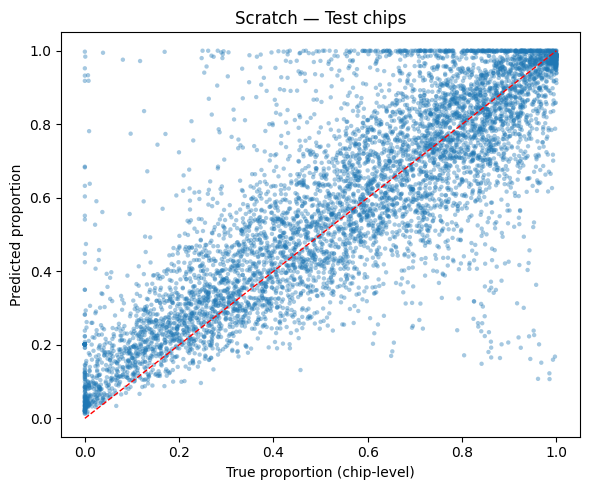

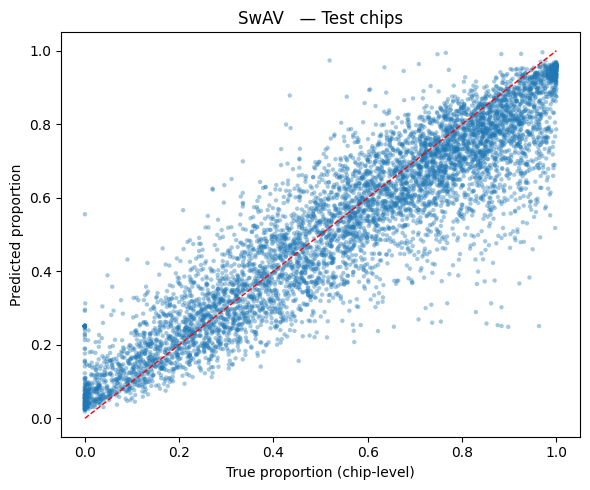

In [28]:
# ===========================================================
# MODULE 10: Scatter plots
# ===========================================================

import matplotlib.pyplot as plt

def scatter_plot(model, X, y, title):
    y_pred = model.predict(X, verbose=0).ravel()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y, y_pred, alpha=0.4, edgecolors='none', s=10)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('True proportion (chip-level)')
    ax.set_ylabel('Predicted proportion')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

scatter_plot(model_scratch, X_test, y_test, 'Scratch — Test chips')
scatter_plot(model_swav,    X_test, y_test, 'SwAV   — Test chips')